In [6]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [7]:
histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_fixed05/stacking_predictions_results.csv')

In [8]:
histogram_cv['predicted_class'] = np.where(histogram_cv['prob_1'] > 0.5, 1, 0)

In [12]:
histogram_cv['contig_length'] = (histogram_cv['contig_name'].str.extract(r'_len-(\d+)(?:_NT)?(?:_|$)', expand=False).astype(int))

In [28]:
false

,fold_idx,mc_name,contig_name,prob_1,ground_truth,n,threshold,threshold_mode,threshold_source,random_seed,iteration,predicted_class,correct_prediction,contig_length,contig_start,contig_end
2699,0,stacking,"LC745662.1_Sewage-associated_tobamovirus_RNA,_...",0.001422,1,10,0.5,fixed,fixed_user,42,1,0,0,6776,0,6776
7986,0,stacking,"LC745662.1_Sewage-associated_tobamovirus_RNA,_...",0.372018,1,10,0.5,fixed,fixed_user,42,3,0,0,6776,0,6776
3036,0,stacking,"NC_015552.1_Passion_fruit_mosaic_virus,_comple...",0.003184,1,10,0.5,fixed,fixed_user,42,1,0,0,6791,0,6791
8256,0,stacking,"NC_015552.1_Passion_fruit_mosaic_virus,_comple...",0.062487,1,10,0.5,fixed,fixed_user,42,3,0,0,6791,0,6791
12576,3,stacking,"NC_015552.1_Passion_fruit_mosaic_virus,_comple...",0.036438,1,10,0.5,fixed,fixed_user,42,4,0,0,6791,0,6791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66947,1,stacking,NC_040685.2_Opuntia_virus_2_isolate_Nopal_hec_...,0.438650,1,10,0.5,fixed,fixed_user,42,25,0,0,693,5430,6123
69040,0,stacking,NC_040685.2_Opuntia_virus_2_isolate_Nopal_hec_...,0.306940,1,10,0.5,fixed,fixed_user,42,26,0,0,693,5430,6123
72276,1,stacking,NC_040685.2_Opuntia_virus_2_isolate_Nopal_hec_...,0.367714,1,10,0.5,fixed,fixed_user,42,27,0,0,693,5430,6123
75935,3,stacking,NC_040685.2_Opuntia_virus_2_isolate_Nopal_hec_...,0.277189,1,10,0.5,fixed,fixed_user,42,28,0,0,693,5430,6123


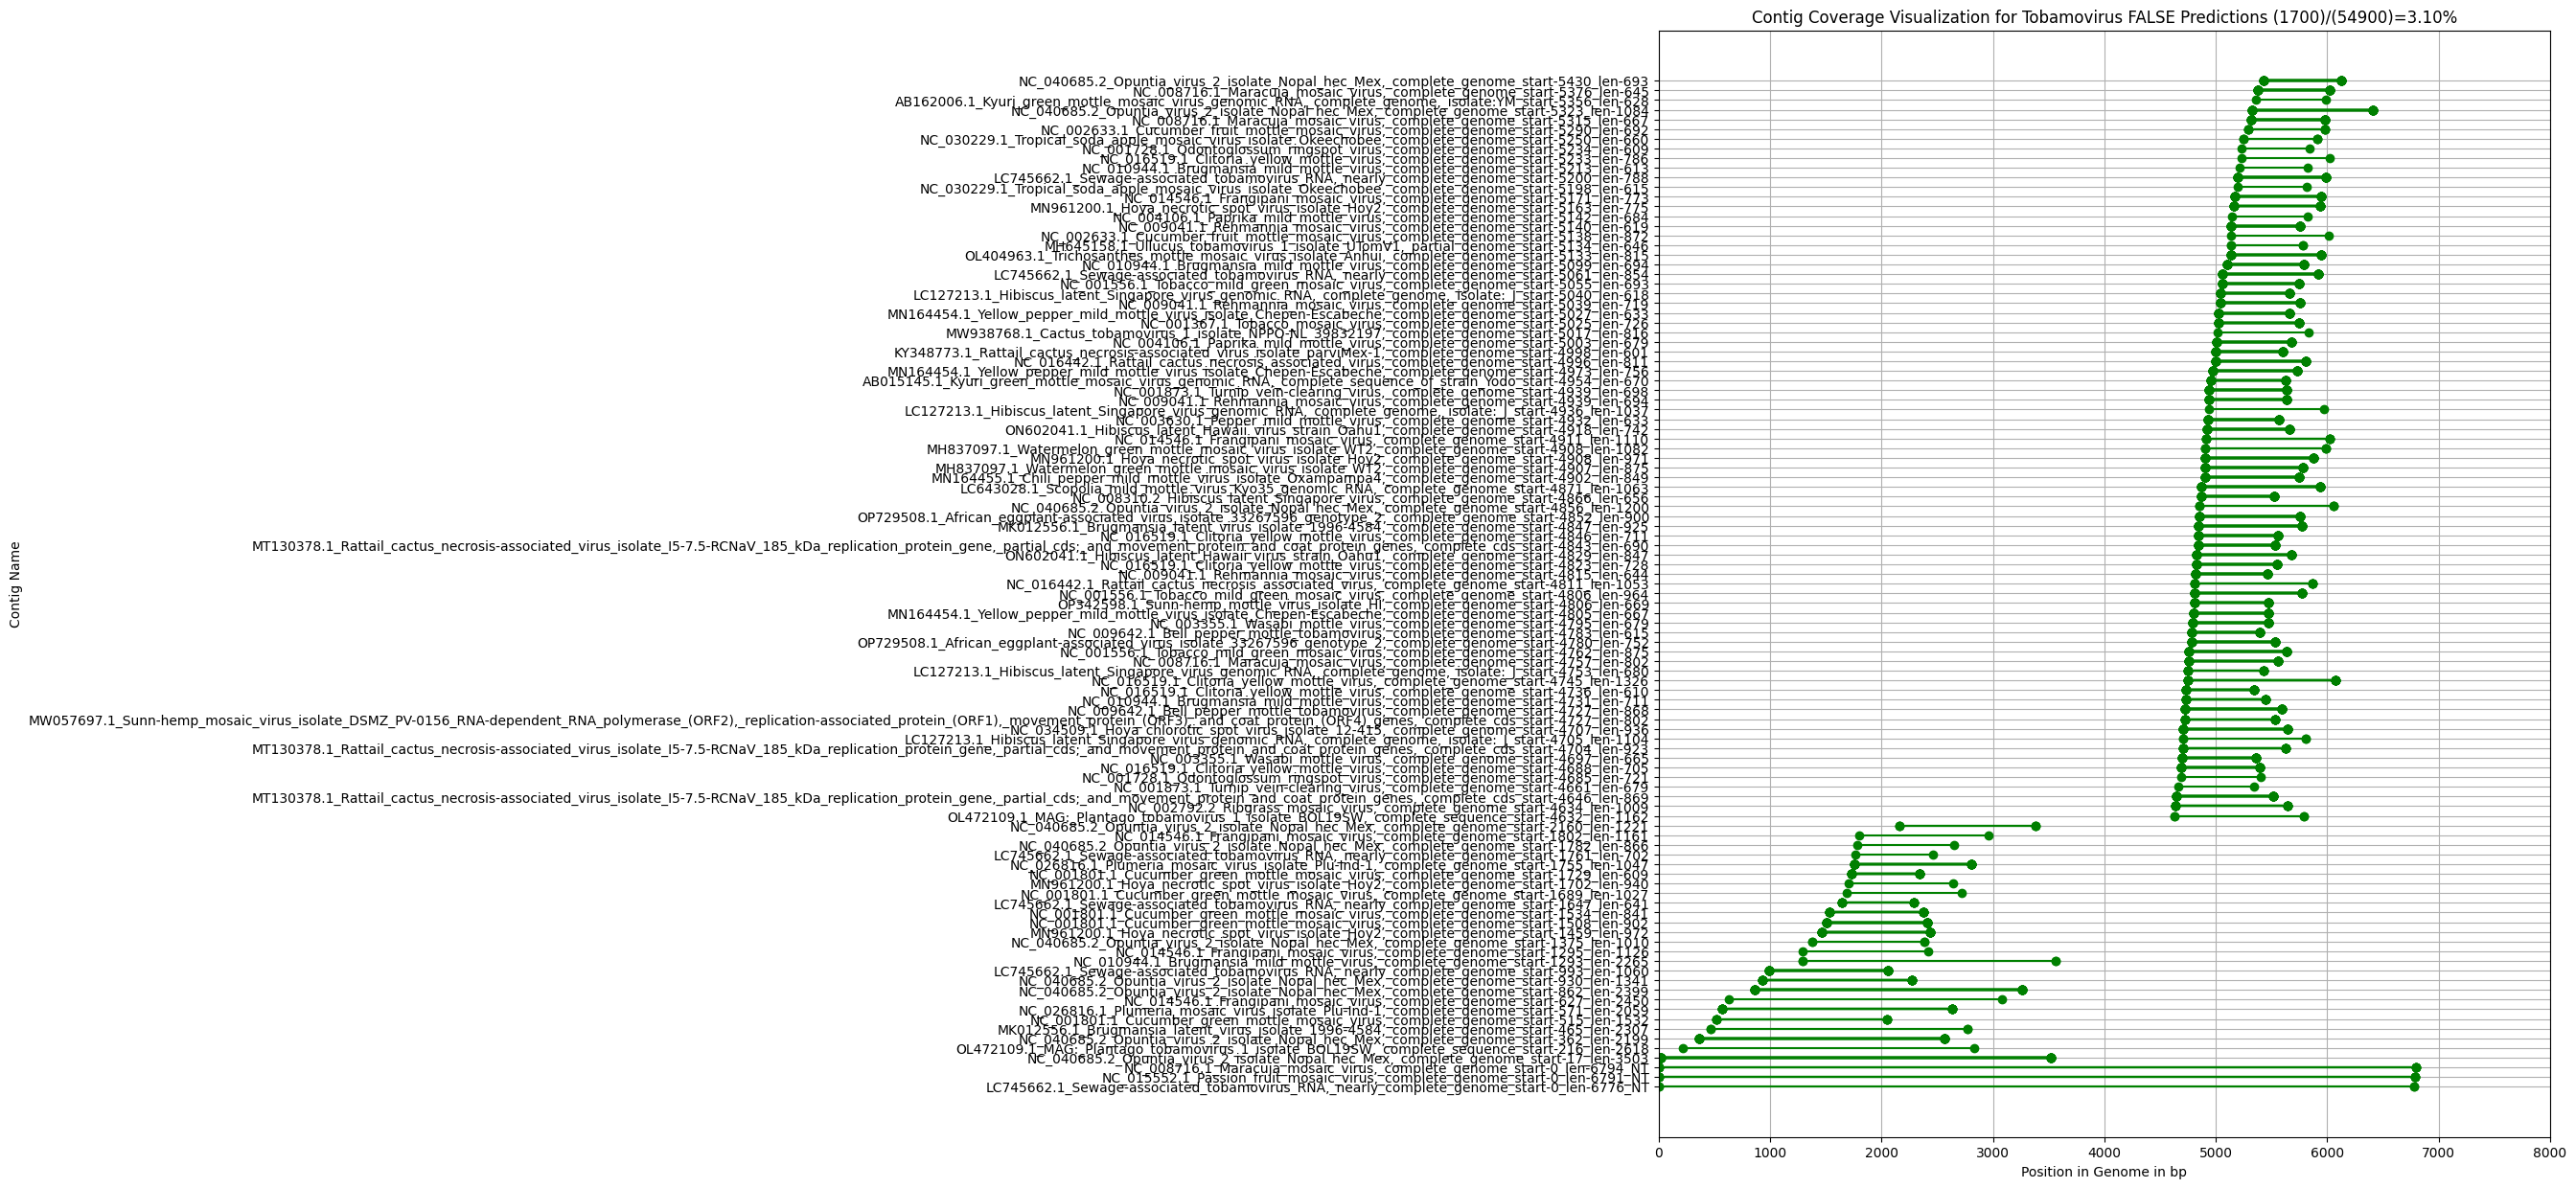

In [27]:
tobamo = histogram_cv[histogram_cv['ground_truth'] == 1]
false = tobamo[tobamo['correct_prediction'] == False].copy()

false['contig_start'] = false['contig_name'].str.extract(r'_start-(\d+)').astype(int)
false['contig_length'] = false['contig_length'].astype(int)
false['contig_end'] = false['contig_start'] + false['contig_length']
false.sort_values(['contig_start', 'contig_length'], inplace=True)

# Create the plot
plt.figure(figsize=(12, 15))
colors = {True: 'green', False: 'orange'}  # Define colors for ground_truth

for _, row in false.iterrows():
    plt.plot([row['contig_start'], row['contig_end']], [row['contig_name'], row['contig_name']], 
            marker='o', color=colors[row['ground_truth']])
    
# Create custom legend handles
true_handle = mlines.Line2D([], [], color='green', marker='o', linestyle='-', markersize=5, label='tobamo')

plt.xlim(0, 8000)
plt.xlabel('Position in Genome in bp')
plt.ylabel('Contig Name')
plt.title(f'Contig Coverage Visualization for Tobamovirus FALSE Predictions ({len(false)})/({len(tobamo)})={(len(false)/len(tobamo)*100):.2f}%')
plt.grid(True)

plt.savefig('false_predictions_contig_coverage.png', dpi=300, bbox_inches='tight')

plt.show()

In [26]:
false.contig_name.nunique()

105

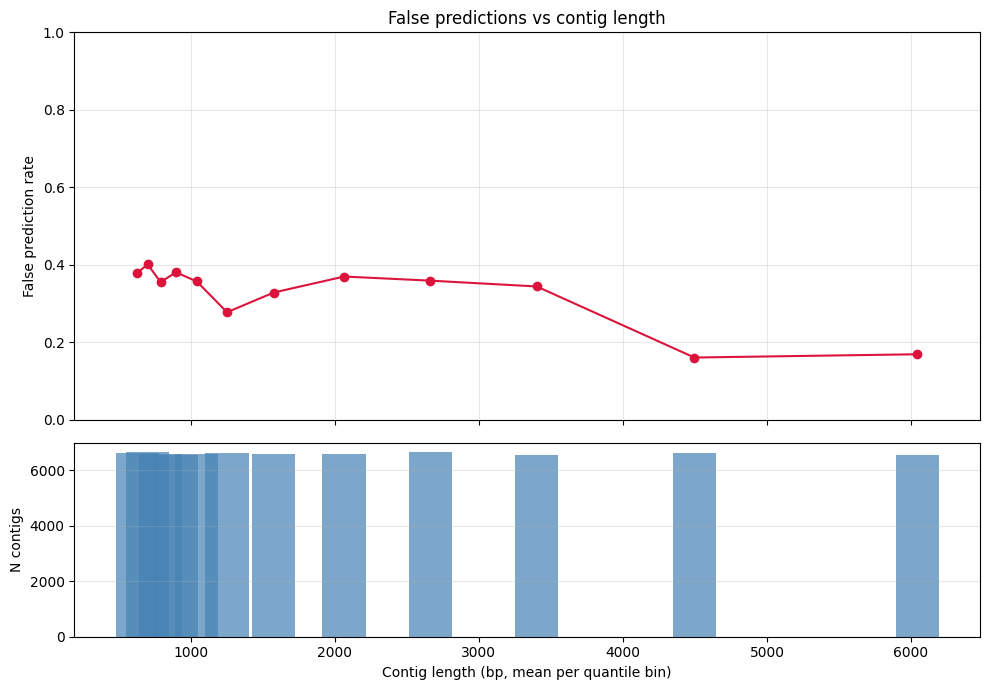

Spearman correlation (contig_length vs false flag): -0.119


In [30]:
# False-prediction correlation with contig length (all rows)
plot_df = histogram_cv[['contig_length', 'correct_prediction']].copy()
plot_df['contig_length'] = pd.to_numeric(plot_df['contig_length'], errors='coerce')
plot_df = plot_df.dropna(subset=['contig_length', 'correct_prediction'])

# Ensure boolean and create false flag
if not pd.api.types.is_bool_dtype(plot_df['correct_prediction']):
    plot_df['correct_prediction'] = (
        plot_df['correct_prediction']
        .astype(str).str.strip().str.lower()
        .map({'true': True, 'false': False, '1': True, '0': False})
    )
plot_df = plot_df.dropna(subset=['correct_prediction'])
plot_df['is_false'] = (~plot_df['correct_prediction']).astype(int)

# Bin contig lengths and compute false rate per bin
n_bins = min(12, int(plot_df['contig_length'].nunique()))
if n_bins < 2:
    plot_df['length_bin'] = pd.cut(plot_df['contig_length'], bins=1)
else:
    plot_df['length_bin'] = pd.qcut(plot_df['contig_length'], q=n_bins, duplicates='drop')

bin_stats = (
    plot_df.groupby('length_bin', observed=True)
    .agg(
        mean_length=('contig_length', 'mean'),
        false_rate=('is_false', 'mean'),
        n=('is_false', 'size')
    )
    .reset_index()
    .sort_values('mean_length')
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]}
)

# False rate trend
ax1.plot(bin_stats['mean_length'], bin_stats['false_rate'], marker='o', color='crimson')
ax1.set_ylabel('False prediction rate')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)
ax1.set_title('False predictions vs contig length')

# Sample count per bin
x_range = bin_stats['mean_length'].max() - bin_stats['mean_length'].min()
bar_width = max(1, x_range / max(1, len(bin_stats) * 1.5))
ax2.bar(bin_stats['mean_length'], bin_stats['n'], width=bar_width, color='steelblue', alpha=0.7)
ax2.set_xlabel('Contig length (bp, mean per quantile bin)')
ax2.set_ylabel('N contigs')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Numeric monotonic correlation
rho = plot_df[['contig_length', 'is_false']].corr(method='spearman').iloc[0, 1]
print(f"Spearman correlation (contig_length vs false flag): {rho:.3f}")